# Task 1 — Prove why we visualize

**Data Visualization — Week 1 assignment, Task 1** · dataset: `data/datasaurus.csv`

The lecture used Anscombe's quartet: 4 datasets, 11 points each, identical statistics. This task repeats the
experiment at a bigger scale — **13 datasets of 142 points each** (the *Datasaurus Dozen*, Matejka &
Fitzmaurice, 2017) — and asks whether the extra data makes summary statistics any more trustworthy.

| Step | What I do |
|---|---|
| 1 | Compute mean, standard deviation and correlation for each of the 13 datasets — one table |
| 2 | Write down what the table alone would make me conclude |
| 3 | Plot all 13 as a grid of scatter plots |
| 4 | Say what I actually found, and answer the question |

## 0. Setup

Same house style as the lecture notebook: the eight-hue colour-blind-safe palette, recessive grid, no chart
border, titles on the left. Every chart below inherits it, and every chart is also saved to `charts/`.

I added one small helper, `footnote()`, because several charts in this task have to **declare excluded
rows on the chart itself**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# ---- House palette (same as the lecture) ---------------------------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA = "#eda100", "#e87ba4"
GREEN, VIOLET, RED = "#008300", "#4a3aa7", "#e34948"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]

INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

# ---- House style ---------------------------------------------------
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_SOFT,
        "axes.titlecolor": INK,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 14,
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": INK_SOFT,
        "ytick.color": INK_SOFT,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "lines.linewidth": 2,
        "font.size": 11,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
    }
)


def save(fig, name):
    # Every chart is also exported to charts/ so it can go straight into a report.
    fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE)


def footnote(ax, text, y=-0.18):
    # Small grey note under the chart - used to declare exclusions ON the chart.
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)


print("Ready. pandas", pd.__version__)

Ready. pandas 3.0.2


---

# Step 1 — The summary statistics

First, check the data is what the brief says it is: 1,846 rows, 13 datasets × 142 points, no gaps.

In [2]:
saurus = pd.read_csv(DATA / "datasaurus.csv")
print("Rows:", saurus.shape[0], " Columns:", saurus.shape[1])
print("Missing values:", int(saurus.isna().sum().sum()))
print("Datasets:", saurus["dataset"].nunique())
print("Points per dataset:", saurus["dataset"].value_counts().unique())
saurus.head()

Rows: 1846  Columns: 3
Missing values: 0
Datasets: 13
Points per dataset: [142]


,dataset,x,y
0,dino,55.3846,97.1795
1,dino,51.5385,96.0256
2,dino,46.1538,94.4872
3,dino,42.8205,91.4103
4,dino,40.7692,88.3333


In [3]:
# The same statistics the lecture computed for Anscombe, one row per dataset.
stats = (
    saurus.groupby("dataset")
    .agg(
        n=("x", "size"),
        mean_x=("x", "mean"),
        mean_y=("y", "mean"),
        std_x=("x", "std"),
        std_y=("y", "std"),
    )
    .round(2)
)
stats["corr_xy"] = (
    saurus.groupby("dataset")
    .apply(lambda g: g["x"].corr(g["y"]), include_groups=False)
    .round(2)
)
stats

,n,mean_x,mean_y,std_x,std_y,corr_xy
dataset,,,,,,
away,142,54.27,47.83,16.77,26.94,-0.06
bullseye,142,54.27,47.83,16.77,26.94,-0.07
circle,142,54.27,47.84,16.76,26.93,-0.07
dino,142,54.26,47.83,16.77,26.94,-0.06
dots,142,54.26,47.84,16.77,26.93,-0.06
h_lines,142,54.26,47.83,16.77,26.94,-0.06
high_lines,142,54.27,47.84,16.77,26.94,-0.07
slant_down,142,54.27,47.84,16.77,26.94,-0.07
slant_up,142,54.27,47.83,16.77,26.94,-0.07


In [4]:
# How different are the 13 datasets, statistic by statistic?
# Largest value minus smallest value across all 13 rows of the table.
spread = (stats.drop(columns="n").max() - stats.drop(columns="n").min()).round(3)
spread.to_frame("max - min across the 13 datasets")

,max - min across the 13 datasets
mean_x,0.01
mean_y,0.01
std_x,0.01
std_y,0.01
corr_xy,0.01


---

# Step 2 — What the table alone says

If this table were all I had, I would conclude:

- **These are 13 samples of the same thing.** Every mean agrees to within 0.01, every standard deviation to
  within 0.01, every correlation to within 0.01. Differences that small look like rounding, not like
  different data.
- **x is centred around 54 and y around 48**, with y spread out more than x (std ≈ 27 vs ≈ 17).
- **x and y are unrelated.** A correlation of about −0.06 is effectively zero, so I would picture each
  dataset as a shapeless, roughly oval cloud of points with no trend.

In short: *one dataset, copied 13 times, and it is a boring cloud.* Let's check.

---

# Step 3 — Plot all 13

A grid of **small multiples**: one scatter plot per dataset, all sharing the same axes so the shapes can be
compared directly. A scatter plot is the only honest choice here — each dataset is two numeric variables,
and the question is *what shape do the points make together*, which is exactly what a scatter shows.

One colour for every panel, because colour would carry no extra information — the panel title already
says which dataset it is. As in the Anscombe chart, each panel also gets its regression line, which is
(almost) the same flat line every time.

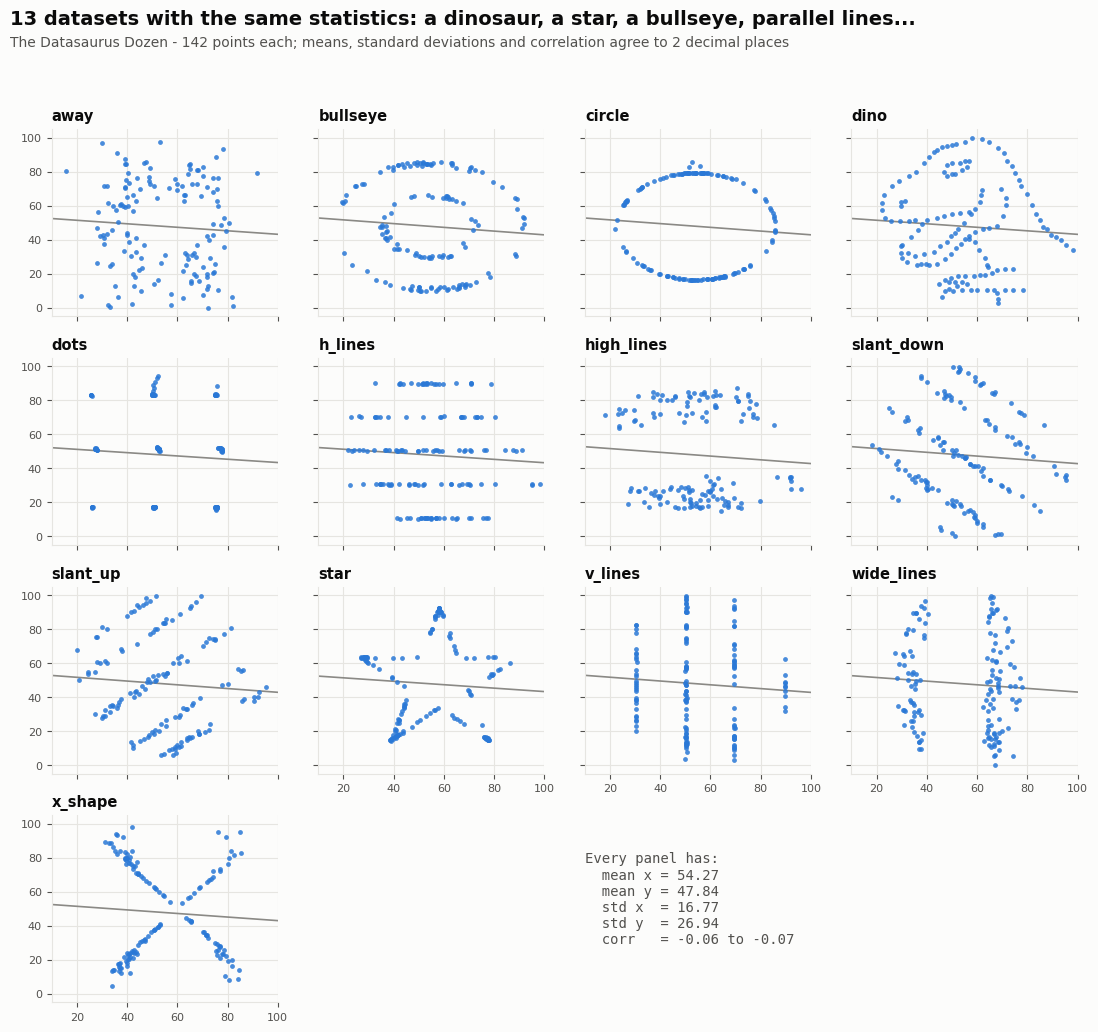

In [5]:
names = stats.index.tolist()

fig, axes = plt.subplots(4, 4, figsize=(11, 10.5), sharex=True, sharey=True)

for ax, name in zip(axes.flat, names):
    group = saurus[saurus["dataset"] == name]
    ax.scatter(group["x"], group["y"], s=12, color=BLUE, alpha=0.85, linewidth=0, zorder=3)

    # The near-identical regression line, drawn on every panel.
    slope, intercept = np.polyfit(group["x"], group["y"], 1)
    xs = np.array([10, 100])
    ax.plot(xs, slope * xs + intercept, color=INK_MUTED, linewidth=1.2, zorder=2)

    ax.set_title(name, fontsize=10.5, loc="left", pad=6)
    ax.set_xlim(10, 100)
    ax.set_ylim(-5, 105)
    ax.tick_params(labelsize=8)

# 13 datasets in a 4 x 4 grid leaves three empty panels: use one for the shared statistics.
for ax in axes.flat[len(names):]:
    ax.axis("off")
# Panels sitting above an empty slot need their own x tick labels.
for ax in axes[2, 1:]:
    ax.xaxis.set_tick_params(labelbottom=True)
axes.flat[-2].text(
    0.0,
    0.55,
    "Every panel has:\n"
    f"  mean x = {stats['mean_x'].mean():.2f}\n"
    f"  mean y = {stats['mean_y'].mean():.2f}\n"
    f"  std x  = {stats['std_x'].mean():.2f}\n"
    f"  std y  = {stats['std_y'].mean():.2f}\n"
    f"  corr   = {stats['corr_xy'].max():.2f} to {stats['corr_xy'].min():.2f}",
    transform=axes.flat[-2].transAxes,
    fontsize=10,
    color=INK_SOFT,
    family="monospace",
    va="center",
)

fig.suptitle(
    "13 datasets with the same statistics: a dinosaur, a star, a bullseye, parallel lines...",
    x=0.005,
    ha="left",
    fontsize=14,
    fontweight="bold",
    color=INK,
)
fig.text(
    0.005,
    0.945,
    "The Datasaurus Dozen - 142 points each; means, standard deviations and correlation agree to 2 decimal places",
    ha="left",
    fontsize=10,
    color=INK_SOFT,
)
fig.tight_layout(rect=[0, 0, 1, 0.935])
save(fig, "task1_datasaurus_grid")
plt.show()

---

# Step 4 — What I actually found

The table said "one boring cloud, 13 times". The picture says almost the opposite: **13 completely different
datasets, and hardly any of them is a cloud.**

- **`dino`** is a drawing of a dinosaur.
- **`star`**, **`bullseye`**, **`circle`** and **`x_shape`** are geometric figures — the bullseye and circle
  are rings with an empty centre, where the "average point" (54, 48) has *no data at all*.
- **`h_lines`** and **`v_lines`** are sets of parallel stripes — the values only take a handful of levels on
  one axis, nothing like a smooth spread. **`high_lines`** and **`wide_lines`** are two separate bands with
  an empty gap through the middle, exactly where the means sit.
- **`slant_up`** and **`slant_down`** are bands of diagonal lines. Inside each band x and y are strongly
  related, yet the overall correlation is still −0.06.
- **`dots`** is a grid of tight clusters with empty space between them.
- **`away`** is the only one that looks like the shapeless cloud the table described — so the table's
  story is true for **1 dataset out of 13**.

The grey regression lines are nearly identical and nearly flat in every panel, and in every panel they
describe the data badly. The correlation of −0.06 is technically correct each time, but it is answering
a question ("is there a single straight-line trend?") that none of these shapes is about.

> The lesson from Anscombe holds at scale: **a number tells you *what*; a picture tells you *why*.**
> Plot first, compute second.

---

## The question: do 13 datasets and 142 points make the statistics more trustworthy?

**No.** More data makes the statistics more *precise*, but not more *informative*.

1. **More points only shrinks sampling error.** With 142 points instead of 11, the mean and correlation are
   estimated more precisely — but they are still estimates of the *same five numbers*. Five numbers cannot
   describe the shape of 142 points, any more than they could describe 11. Compression throws away the
   shape no matter how big the input is.
2. **More points give more freedom to hide structure, not less.** With 11 points Anscombe could only build
   four rough variations. With 142 points the authors could draw a dinosaur, a star and a bullseye while
   pinning the statistics in place. In fact the Datasaurus sets were *generated deliberately*: starting
   from the dinosaur, points were nudged a tiny step at a time towards a target shape, and a move was only
   kept if the statistics stayed the same to two decimal places. That this works at all shows how many
   different datasets share one summary.
3. **More datasets do not help either.** Thirteen agreeing tables feel like thirteen confirmations, but they
   are thirteen copies of the same blind spot. Agreement between summaries says nothing about agreement
   between the data.

The only thing that made these statistics trustworthy — or rather, showed that they are *not* — was
looking at the points. That is the case for visualizing, made with 1,846 rows instead of 44.